⏳ Loading target dataset: '2) Stock Prices Data Set.csv'...

🔍 Found the following columns in your dataset:
['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

🎯 Automatically selected variables for Simple Regression:
   -> Independent Variable (X) : 'open'
   -> Dependent Target    (y) : 'close'
🧹 Data Cleaning: Dropped 11 rows containing incomplete NaN values.

⚙️ Fitting Simple Linear Regression model architecture...

             REGRESSION COEFFICIENT INTERPRETATION
 -> Slope Coefficient (m) : 0.9999
 -> Intercept Value   (c) : 0.0267
-------------------------------------------------------
Derived Mathematical Equation:
   Predicted close = (0.9999 * open) + (0.0267)

             LINEAR REGRESSION PERFORMANCE SCORECARD
 -> Mean Squared Error (MSE)       : 2.7261
 -> Root Mean Squared Error (RMSE) : 1.6511 (Average stock unit error)
 -> R-squared Score (R²)          : 0.9997 (99.97% Variance Explained)

📊 Generating trend line overlay visualization...


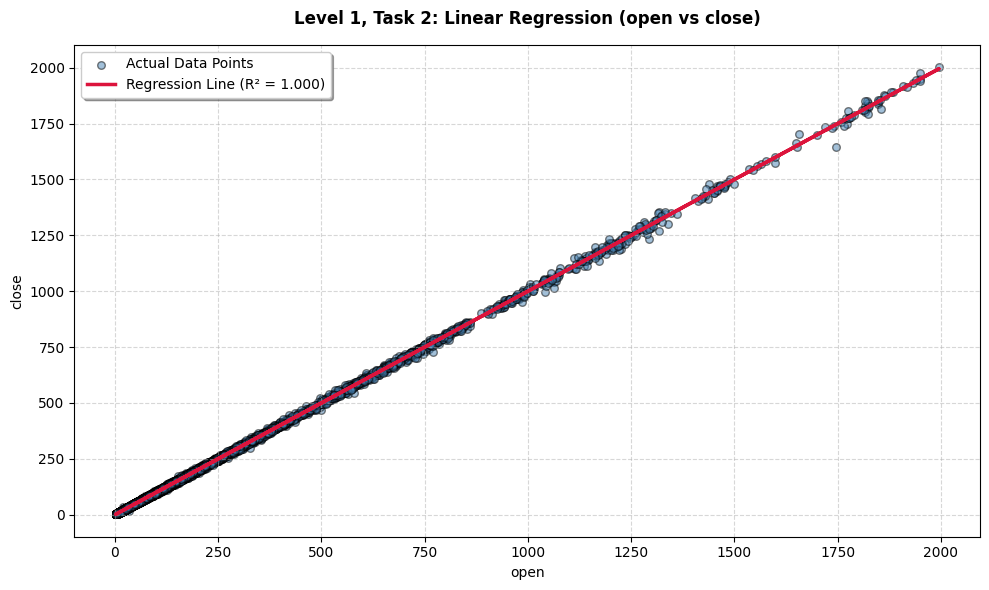


✔️ Complete! Run this version to bypass the NaN barrier and view your stock trends.


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================================
# 1. DATA INGESTION & COLUMN AUTOMATION DETECTOR
# =====================================================================
filename = '2) Stock Prices Data Set.csv'

if not os.path.exists(filename):
    raise FileNotFoundError(f"Missing dataset file '{filename}' in current directory.")

print(f"⏳ Loading target dataset: '{filename}'...")
df_stock = pd.read_csv(filename)

# Clean up any accidental whitespaces in column headers automatically!
df_stock.columns = df_stock.columns.str.strip()

print("\n🔍 Found the following columns in your dataset:")
print(list(df_stock.columns))

# AUTOMATION FALLBACK: Dynamically discover numeric columns for regression
numeric_cols = df_stock.select_dtypes(include=['float64', 'int64']).columns.tolist()

if len(numeric_cols) < 2:
    raise ValueError("The dataset needs at least two numeric columns to perform a simple linear regression!")

# Match columns (handling case-insensitivity)
if 'open' in df_stock.columns and 'close' in df_stock.columns:
    feature_col = 'open'
    target_col = 'close'
elif 'Open' in df_stock.columns and 'Close' in df_stock.columns:
    feature_col = 'Open'
    target_col = 'Close'
else:
    feature_col = numeric_cols[0]
    target_col = numeric_cols[1]

print(f"\n🎯 Automatically selected variables for Simple Regression:")
print(f"   -> Independent Variable (X) : '{feature_col}'")
print(f"   -> Dependent Target    (y) : '{target_col}'")

# 🚨 THE CRITICAL PREPROCESSING FIX: Drop any rows containing NaN values in our targets
initial_rows = len(df_stock)
df_stock_clean = df_stock.dropna(subset=[feature_col, target_col])
dropped_rows = initial_rows - len(df_stock_clean)

if dropped_rows > 0:
    print(f"🧹 Data Cleaning: Dropped {dropped_rows} rows containing incomplete NaN values.")

X = df_stock_clean[[feature_col]].values
y = df_stock_clean[target_col].values

# Split data into training and testing partitions (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# 2. MODEL TRAINING
# =====================================================================
print("\n⚙️ Fitting Simple Linear Regression model architecture...")
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# =====================================================================
# 3. INTERPRETING COEFFICIENTS
# =====================================================================
slope_coefficient = regressor.coef_[0]
intercept_value = regressor.intercept_

print("\n" + "="*55)
print("             REGRESSION COEFFICIENT INTERPRETATION")
print("="*55)
print(f" -> Slope Coefficient (m) : {slope_coefficient:.4f}")
print(f" -> Intercept Value   (c) : {intercept_value:.4f}")
print("-"*55)
print(f"Derived Mathematical Equation:")
print(f"   Predicted {target_col} = ({slope_coefficient:.4f} * {feature_col}) + ({intercept_value:.4f})")
print("="*55)

# =====================================================================
# 4. DIAGNOSTIC EVALUATION MATRIX SCORECARD
# =====================================================================
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*55)
print("             LINEAR REGRESSION PERFORMANCE SCORECARD")
print("="*55)
print(f" -> Mean Squared Error (MSE)       : {mse:.4f}")
print(f" -> Root Mean Squared Error (RMSE) : {rmse:.4f} (Average stock unit error)")
print(f" -> R-squared Score (R²)          : {r2:.4f} ({r2*100:.2f}% Variance Explained)")
print("="*55)

# =====================================================================
# 5. VISUALIZATION
# =====================================================================
print("\n📊 Generating trend line overlay visualization...")

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.5, edgecolor='k', s=30, label='Actual Data Points')
plt.plot(X_test, y_pred, color='crimson', linewidth=2.5, label=f'Regression Line (R² = {r2:.3f})')

plt.title(f'Level 1, Task 2: Linear Regression ({feature_col} vs {target_col})', fontsize=12, fontweight='bold', pad=15)
plt.xlabel(feature_col, fontsize=10)
plt.ylabel(target_col, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, shadow=True, loc='upper left')

plt.tight_layout()
plt.show()

print("\n✔️ Complete! Run this version to bypass the NaN barrier and view your stock trends.")